# 03 - Feature Engineering & Visualization

Domain-knowledge-driven categorical features are created (clinical thresholds for Insulin, Glucose, BloodPressure, BMI, Age), then explored visually alongside correlations and the target distribution.

In [1]:
import sys
sys.path.append("..")

import pandas as pd

from src.eda import grab_col_names
from src.feature_engineering import feature_extraction
from src.visualization import (
    plot_correlation_heatmap, boxplot_for_outliers, hist_plot,
    plot_target_distribution, plot_categorical_features_vs_target,
)

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("../data/diabetes.csv")
df_cleaned = pd.read_csv("../data/diabetes_cleaned.csv")
cat_cols, num_cols, cat_but_car = grab_col_names(df_cleaned, print_results=False)

## Correlation

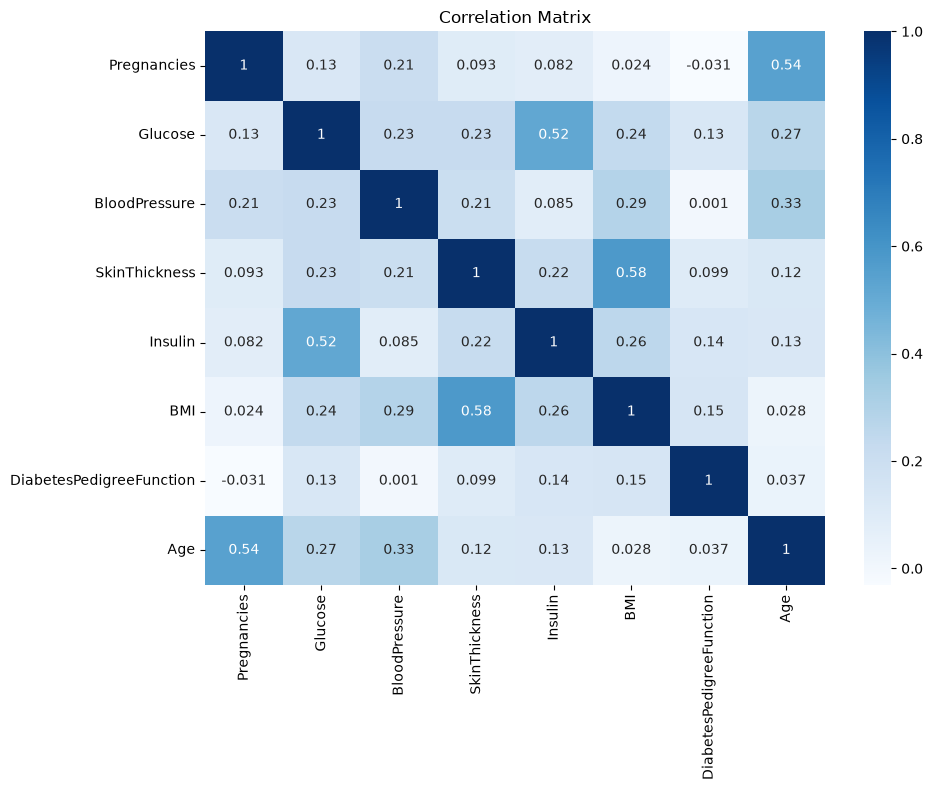

In [3]:
plot_correlation_heatmap(df_cleaned, num_cols)

## Feature extraction

New features:
- `Insulin_CAT`, `Glucose_CAT`: Normal / Prediabetes / Diabetes bands
- `BloodPressure_CAT`: hypertension bands
- `BMI_CAT`: WHO BMI bands
- `Age_CAT`: age groups
- `Life_Level_CAT`: combined risk flag (age > 40, hypertensive, overweight/obese)

In [4]:
feature_extraction(df_cleaned)
df_cleaned.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Insulin_CAT,BloodPressure_CAT,Glucose_CAT,BMI_CAT,Age_CAT,Life_Level_CAT
0,6.0,148.0,72.0,35.0,169.5,33.6,0.627,50.0,1,Prediabetes,Normal,Impaired_Glucose_Tolerance,Obese_Class1,Middle_Age_Adult,Not_Risk
1,1.0,85.0,66.0,29.0,102.5,26.6,0.351,31.0,0,Normal,Normal,Normal,Overweight,Adult,Not_Risk
2,8.0,183.0,64.0,32.0,169.5,23.3,0.672,32.0,1,Prediabetes,Normal,Impaired_Glucose_Tolerance,Healthy,Adult,Not_Risk
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0,Normal,Normal,Normal,Overweight,Adult,Not_Risk
4,0.0,137.0,40.0,35.0,168.0,43.1,1.949,33.0,1,Prediabetes,Low_Blood_Pressure,Normal,Obese_Class3,Adult,Not_Risk


## Visualization - outliers (before / after)

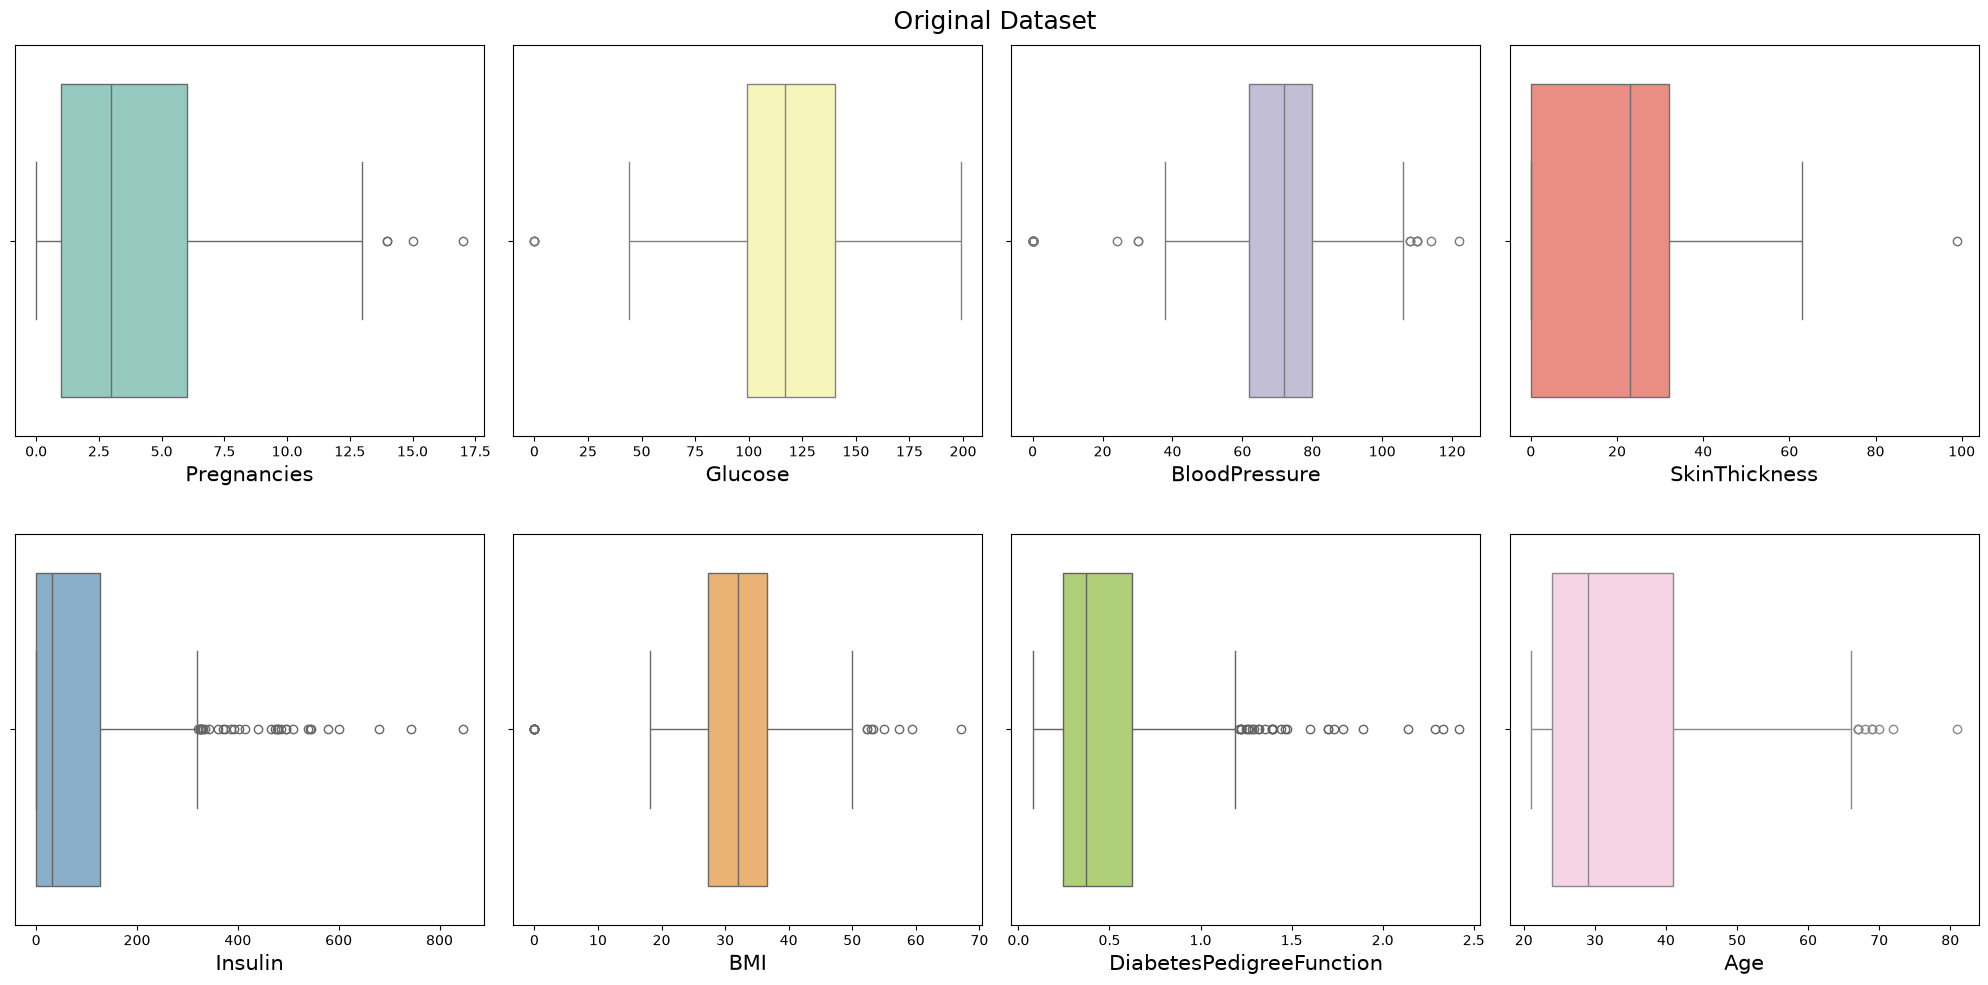

In [5]:
boxplot_for_outliers(df, num_cols, title='Original Dataset')

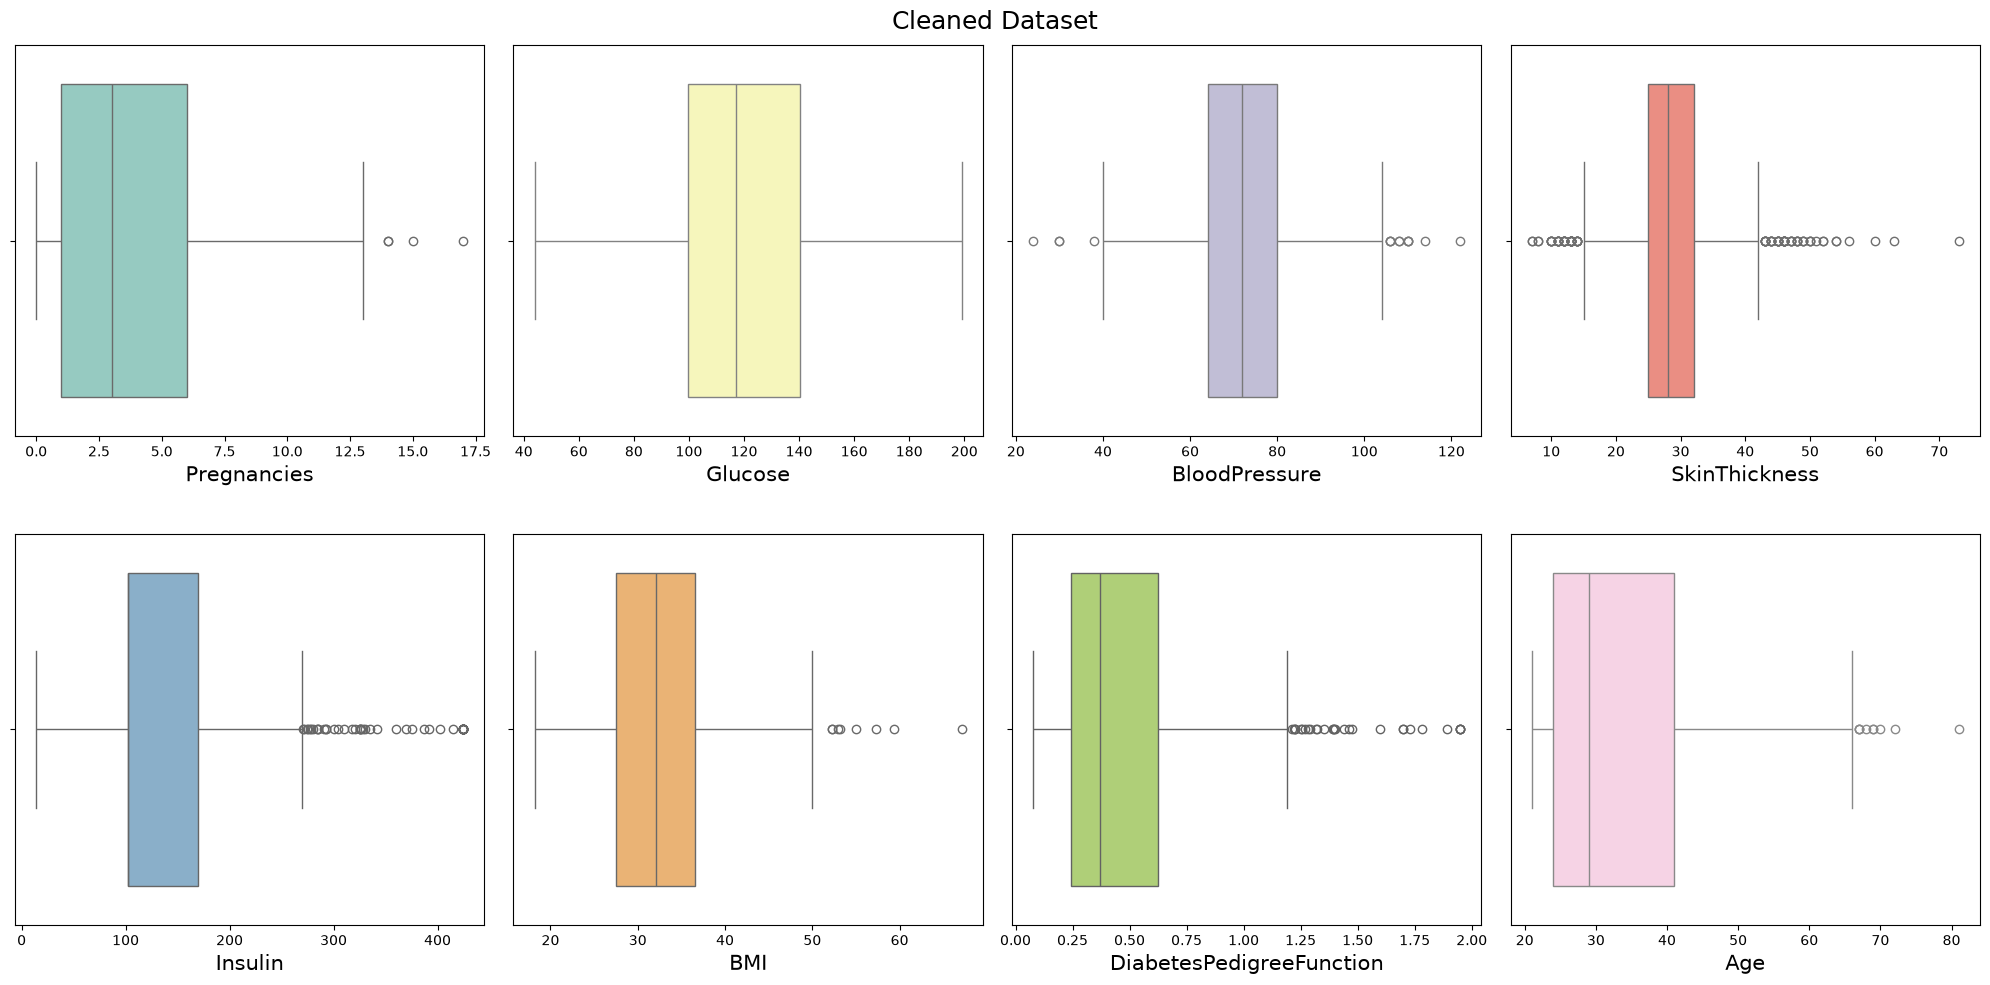

In [6]:
boxplot_for_outliers(df_cleaned, num_cols, title='Cleaned Dataset')

## Visualization - distributions

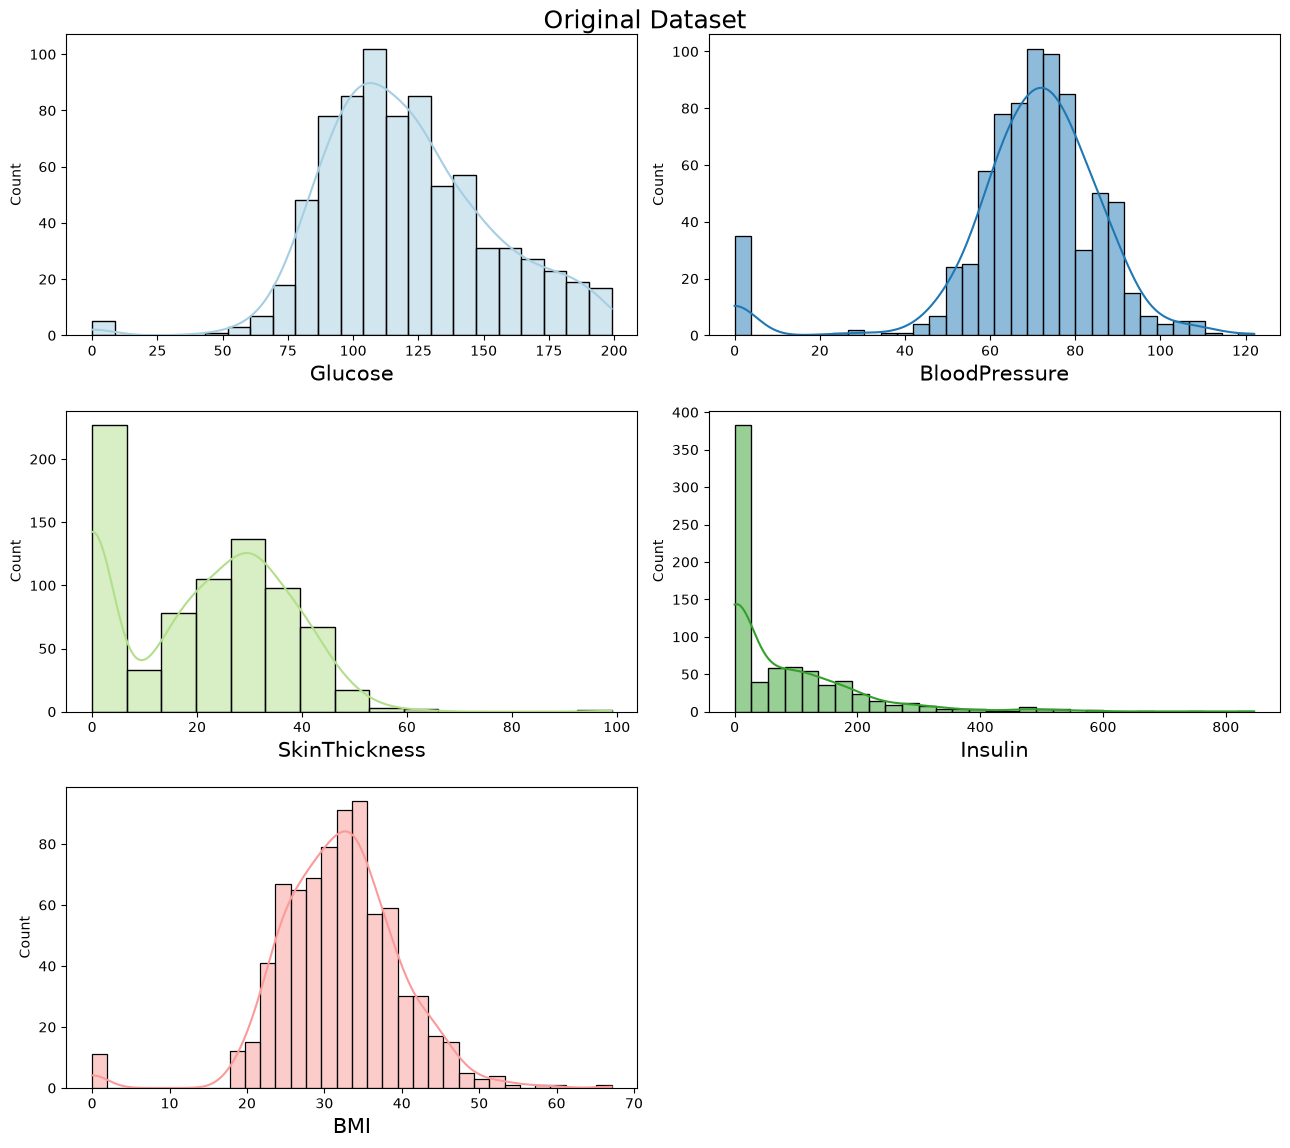

In [7]:
missing_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
hist_plot(df, missing_cols, title='Original Dataset')

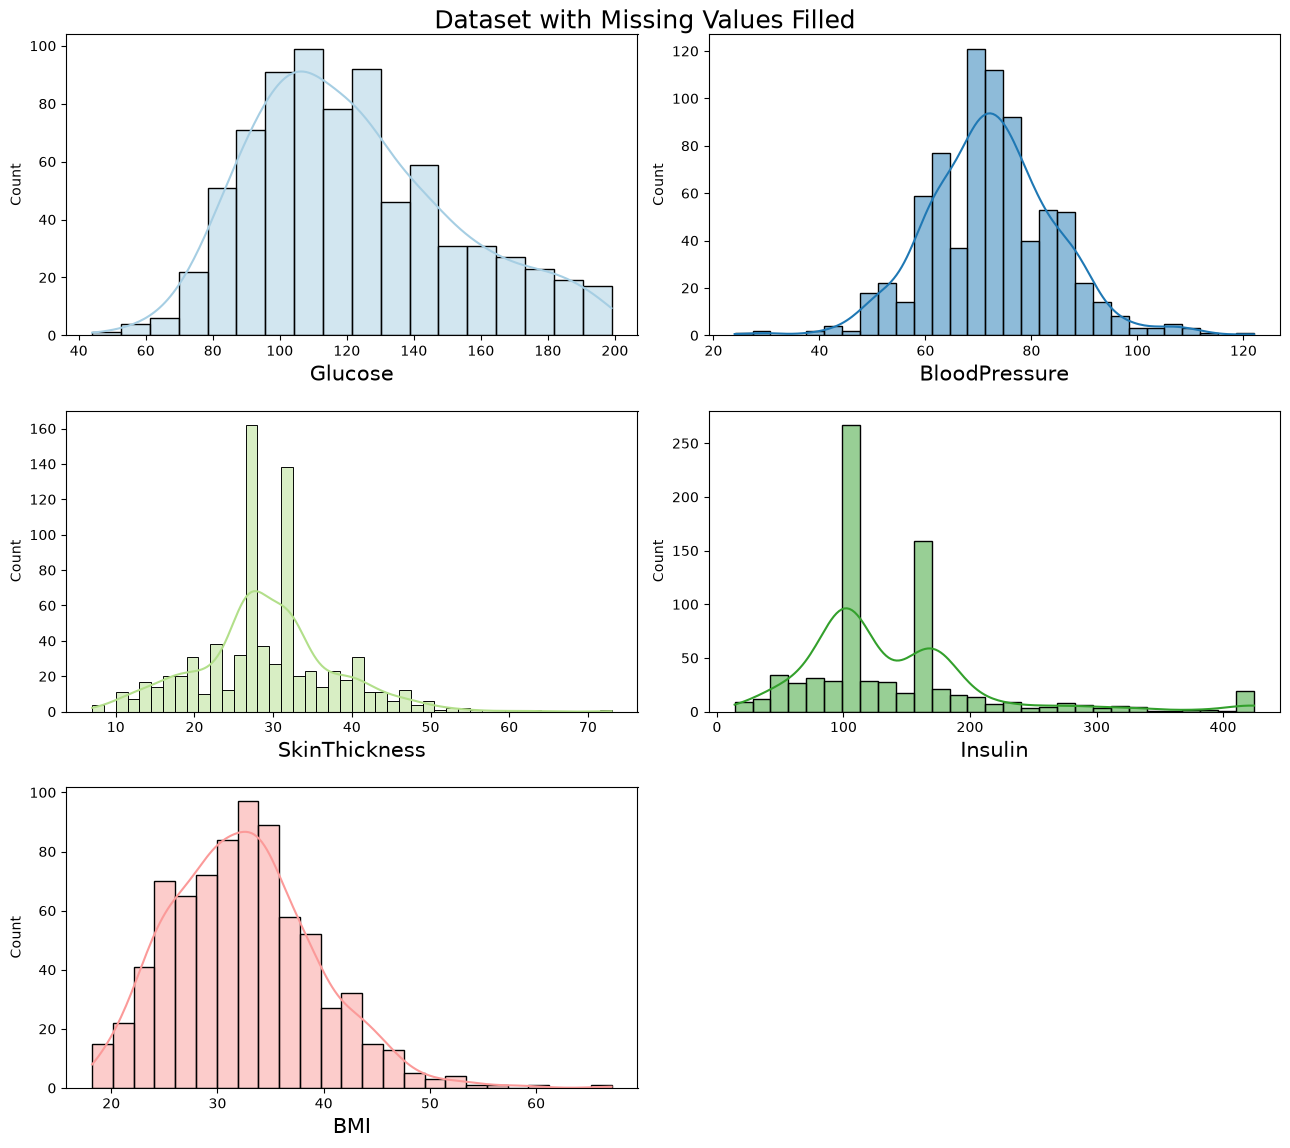

In [8]:
hist_plot(df_cleaned, missing_cols, title='Dataset with Missing Values Filled')

## Visualization - target ratio

C:\Users\MSI\Downloads\diabetes-prediction (2)\diabetes-prediction\notebooks\..\src\visualization.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


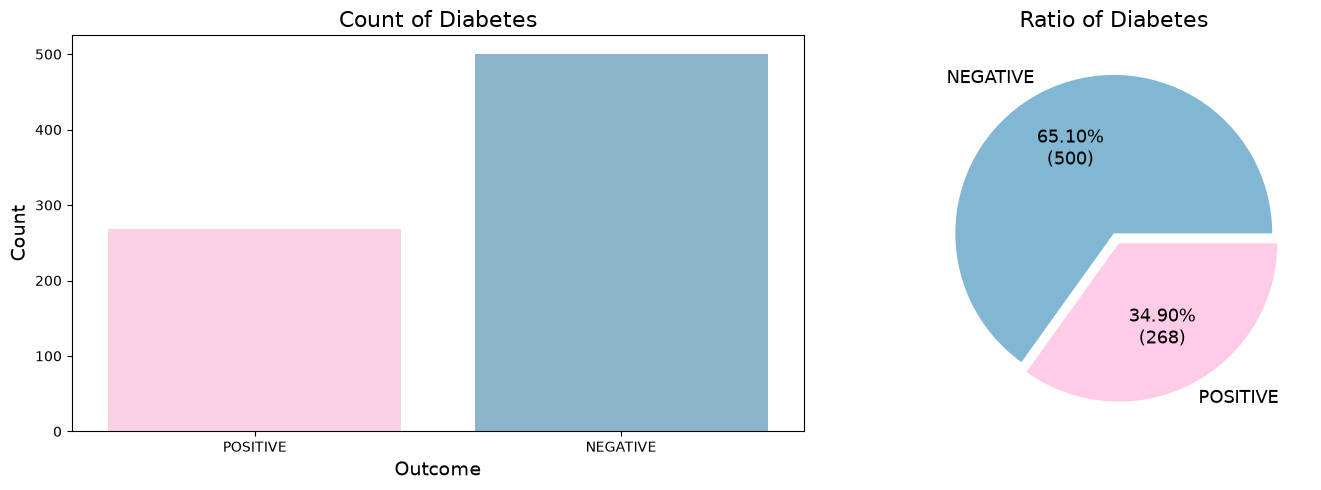

In [9]:
plot_target_distribution(df_cleaned)

## Visualization - engineered features vs target

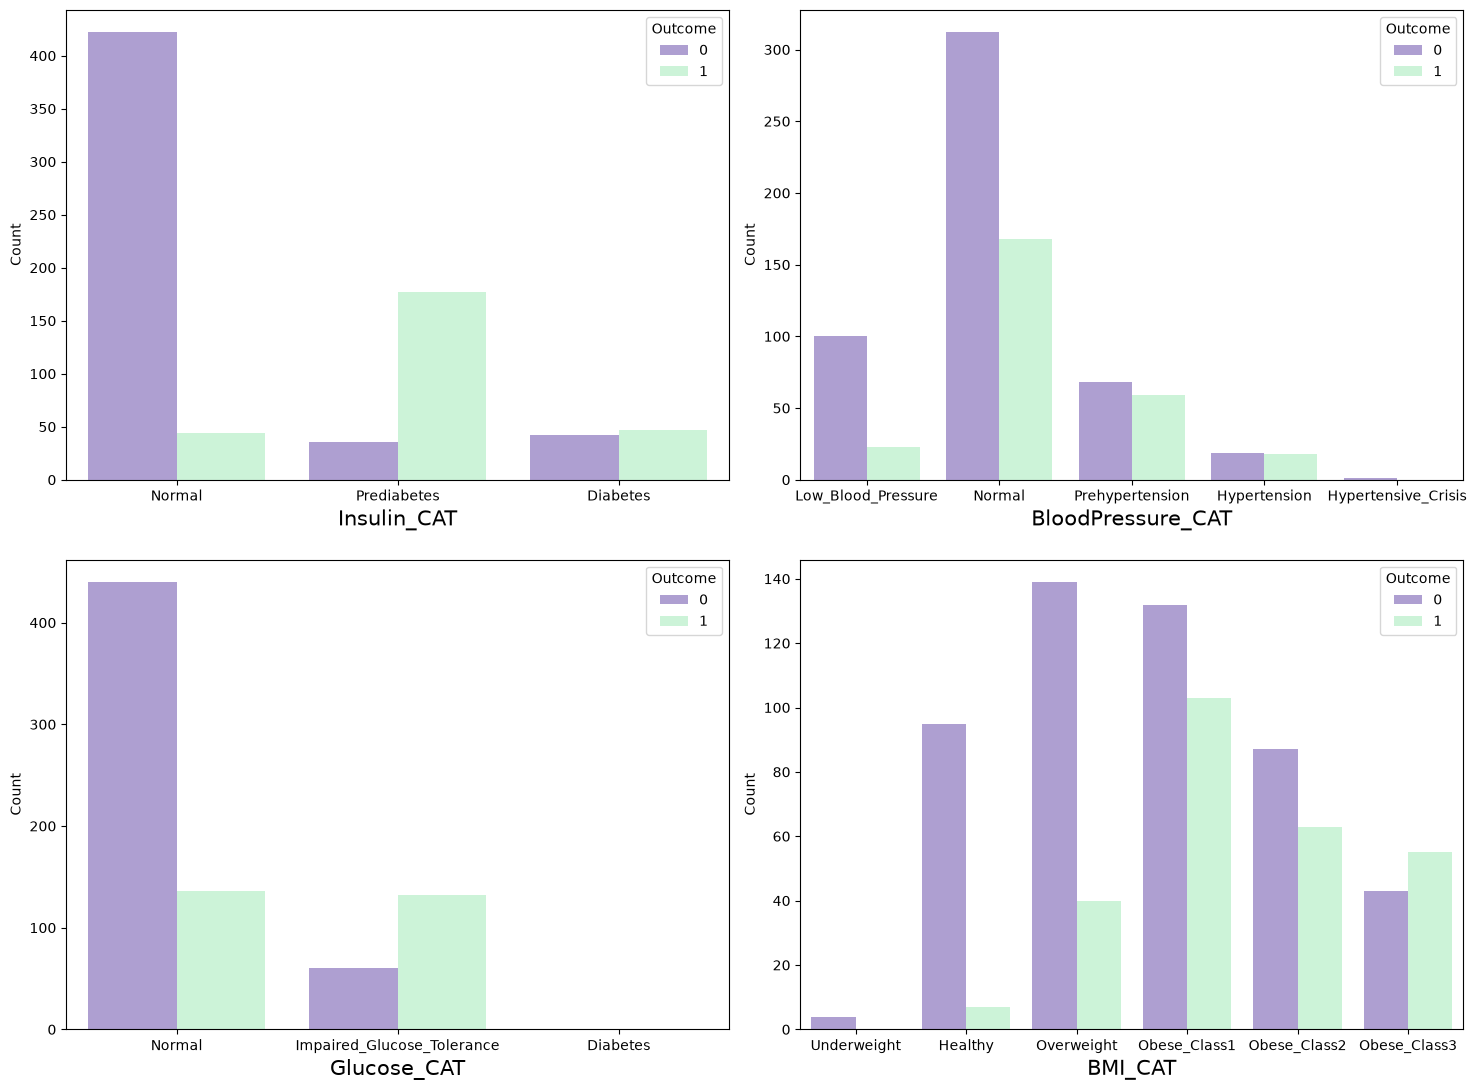

In [10]:
new_cols = ["Insulin_CAT", "BloodPressure_CAT", "Glucose_CAT", "BMI_CAT"]
plot_categorical_features_vs_target(df_cleaned, new_cols)

In [11]:
df_cleaned.to_csv("../data/diabetes_features.csv", index=False)